In [1]:
import cafe

cafe.logger.setLevel("DEBUG")
# cafe.settings.backend = "python_function"
cafe.settings.backend = "conda"

[08/27/2025 04:44:13] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

Data

In [2]:
import pandas as pd
import scanpy as sc

# creating from Anndata
adata = sc.read_h5ad(f"../../tests/data/bifurcating.h5ad")
fadata = cafe.data.FateAnnData.from_anndata(adata)

cluster_key = "lineage"
fadata.obs.index = fadata.obs["cell_id"].tolist()

fadata

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             


AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced'

Method

In [ ]:
parameters = {
    "start_id": "cell1",
    "cluster_key": "lineage",
    "connectivity_cutoff": 0.5,
}

# method name string is recommended for benchmark 
# method = cafe.method.FateMethod(method_name="paga")
# method(fadata, **parameters)  # add parameters when inferring trajectory

# method object is recommended for benchmark
# TODO: remove check prior information 
cafe.method.paga(fadata, **parameters)

# help(cafe.method.paga) # __doc__ is reassign

                      DEBUG    CondaBackend __init__                                                                                                                                                    
                      INFO     method_backend: CondaBackend: function_name-cf_paga, load_backend-cfe                                                                                                    
                      DEBUG    Temp wd: /tmp/tmpd4s42oq5                                                                                                                                                
                      INFO     cmd: conda run -n cfe --no-capture-output python /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/parse_args.py --function_name=cf_paga    
                               --adata_path=/tmp/tmpd4s42oq5/adata.h5ad --prior_information=/tmp/tmpd4s42oq5/prior_information.json --parameters=/tmp/tmpd4s42oq5/parameters.json                   

Plot

                      DEBUG    plot_trajectory                                                                                                                                                          
[07/24/2025 09:05:39] DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
[07/24/2025 09:05:40] DEBUG    add waypoints shape is (208, 1000), finished!                                                                                                                            


<Axes: title={'center': 'milestone'}, xlabel='UMAP1', ylabel='UMAP2'>

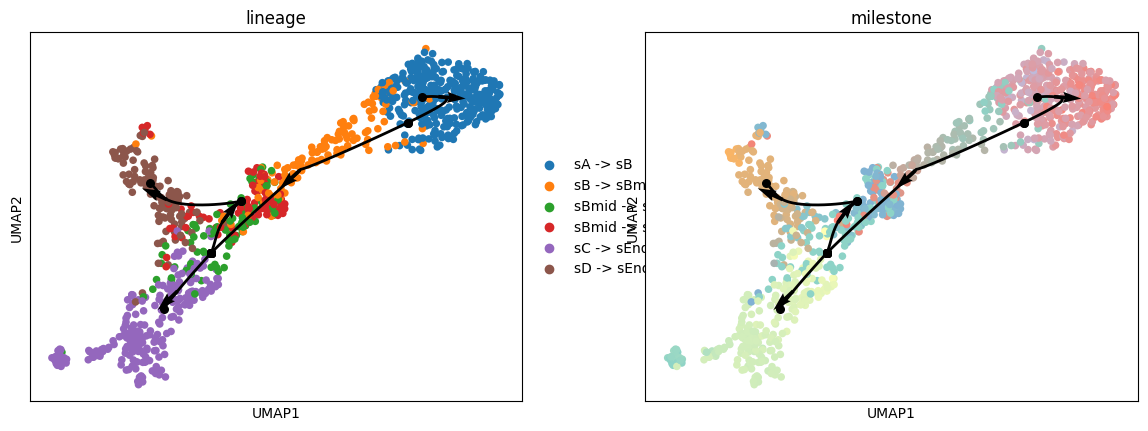

In [ ]:
cafe.plot.plot_trajectory(fadata, basis="umap", color=["lineage", "milestone"])

Save

In [5]:
fadata.write_h5ad("output.h5ad")

[07/24/2025 09:05:45] DEBUG    transfer milestone color from tuple to list                                                                                                                              
                      DEBUG    transfer trajectory history: '20250724_210535__paga-python_function__ky1cdQfAGo' to dict                                                                                 
